Abas encontradas: ['Seguimento prévio', 'Recolha_de_Dados', 'Listas_Dropdowns']

Colunas seguimento: ['nome', 'nsc', 'data de internamento']
Colunas recolha: ['  ', 'nº processo ', 'Data de nascimento', 'Idade ', 'Sexo', 'Doença crónica PRÉVIA', 'Doença psiquiátrica prévia', 'Qual', 'Data de admissao na UCIPed', 'Data_alta_UCIPed', 'Tempo_total_UCIP_dias', 'Diagnóstico_admissao_principal', 'Categoria_diagnóstico', 'Ventilação ', 'Dias de ventilação', 'Sedo-analgia', 'Dias de sedoanalgesia', 'Motivo de apoio psicológico', 'Unnamed: 18', 'Medicação psiquiátrica iniciada', 'Alta UCIP destino', 'Seguimento psic após alta', 'Duração do seguimento']
[AVISO] Seguimento: não achei coluna ID comum. Vou usar a PRIMEIRA coluna: 'nome'
[AVISO] Recolha: não achei coluna ID comum. Vou usar a PRIMEIRA coluna: '  '

===== CONTAGENS =====
Seguimento prévio: 42
Pedopsiquiatria: 38
Ambos: 16

Distribuição:
 Categoria
Só Seguimento         26
Só Pedopsiquiatria    22
Ambos                 16
Name: count, 

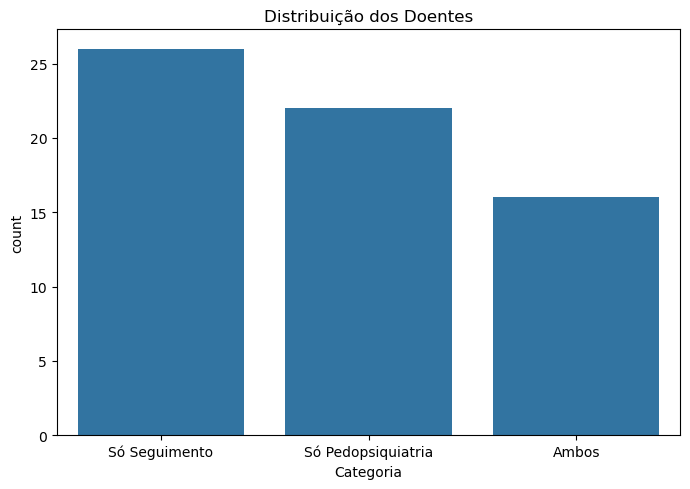

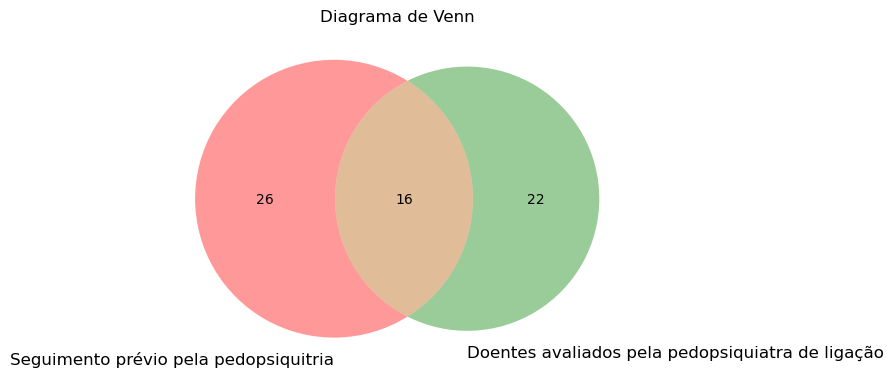


===== PERCENTAGENS =====
Seguimento: 65.62 %
Pedopsiquiatria: 59.38 %
Ambos: 25.0 %

===== TABELA 2x2 =====
              Seguimento SIM  Seguimento NÃO
Pedopsiq SIM              16              26
Pedopsiq NÃO              22               0

Qui-quadrado: 20.442715179557283
p-valor (chi2): 6.14429830716848e-06
Mínimo esperado: 8.9375

Odds Ratio (com correção +0.5 por causa de zeros): 0.014

Salvei 'ids_intersecao.xlsx' com os IDs que estão em ambos.


In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib_venn import venn2
from scipy.stats import chi2_contingency, fisher_exact

arquivo = "data.xlsx"

# -----------------------------
# 1) Descobrir nomes das abas
# -----------------------------
xls = pd.ExcelFile(arquivo)
print("Abas encontradas:", xls.sheet_names)

# Ajuste aqui se necessário (mas primeiro veja o print acima)
sheet_seguimento = "Seguimento prévio"
sheet_recolha = "Recolha_de_Dados"

df_seguimento = pd.read_excel(arquivo, sheet_name=sheet_seguimento)
df_recolha = pd.read_excel(arquivo, sheet_name=sheet_recolha)

print("\nColunas seguimento:", list(df_seguimento.columns))
print("Colunas recolha:", list(df_recolha.columns))

# -----------------------------
# 2) Escolher coluna de ID
# -----------------------------
# Se "ID" não existir, tenta achar automaticamente por nomes comuns
candidatos = ["ID", "Id", "id", "N_PROCESSO", "Processo", "Nº Processo", "Nr Processo", "Numero", "Nº", "Utente", "Doente"]

def achar_coluna_id(df, nome_df):
    for c in candidatos:
        if c in df.columns:
            print(f"[OK] {nome_df}: coluna de ID = '{c}'")
            return c
    # fallback: primeira coluna
    print(f"[AVISO] {nome_df}: não achei coluna ID comum. Vou usar a PRIMEIRA coluna: '{df.columns[0]}'")
    return df.columns[0]

col_id_seguimento = achar_coluna_id(df_seguimento, "Seguimento")
col_id_recolha = achar_coluna_id(df_recolha, "Recolha")

# -----------------------------
# 3) Normalizar IDs (evitar espaços, NaN, floats)
# -----------------------------
def normalizar_ids(series):
    s = series.dropna().astype(str).str.strip()
    # remove ".0" típico quando Excel vira float (ex: 123.0)
    s = s.str.replace(r"\.0$", "", regex=True)
    # remove strings vazias
    s = s[s != ""]
    return set(s)

ids_seguimento = normalizar_ids(df_seguimento[col_id_seguimento])
ids_recolha = normalizar_ids(df_recolha[col_id_recolha])

intersecao = ids_seguimento & ids_recolha
total_ids = ids_seguimento | ids_recolha

# -----------------------------
# 4) Contagens
# -----------------------------
print("\n===== CONTAGENS =====")
print("Seguimento prévio:", len(ids_seguimento))
print("Pedopsiquiatria:", len(ids_recolha))
print("Ambos:", len(intersecao))

# -----------------------------
# 5) DataFrame categórico
# -----------------------------
dados = []
for id_ in total_ids:
    if id_ in intersecao:
        cat = "Ambos"
    elif id_ in ids_seguimento:
        cat = "Só Seguimento"
    else:
        cat = "Só Pedopsiquiatria"
    dados.append([id_, cat])

df_relacao = pd.DataFrame(dados, columns=["ID", "Categoria"])
print("\nDistribuição:\n", df_relacao["Categoria"].value_counts())

# -----------------------------
# 6) Gráfico de barras
# -----------------------------
plt.figure(figsize=(7,5))
sns.countplot(data=df_relacao, x="Categoria", order=["Só Seguimento", "Só Pedopsiquiatria", "Ambos"])
plt.title("Distribuição dos Doentes")
plt.tight_layout()
plt.show()

# -----------------------------
# 7) Diagrama de Venn
# -----------------------------
plt.figure(figsize=(6,6))
venn2([ids_seguimento, ids_recolha],
      set_labels=("Seguimento prévio pela pedopsiquitria", 
                  "Doentes avaliados pela pedopsiquiatra de ligação"))
plt.title("Diagrama de Venn")
plt.show()

# -----------------------------
# 8) Percentagens
# -----------------------------
total = len(total_ids) if len(total_ids) > 0 else 1
print("\n===== PERCENTAGENS =====")
print("Seguimento:", round(len(ids_seguimento)/total*100,2), "%")
print("Pedopsiquiatria:", round(len(ids_recolha)/total*100,2), "%")
print("Ambos:", round(len(intersecao)/total*100,2), "%")

# -----------------------------
# 9) Associação: Qui-quadrado (ou Fisher se contagens baixas)
# -----------------------------
a = len(intersecao)
b = len(ids_seguimento) - a
c = len(ids_recolha) - a
d = len(total_ids) - (a + b + c)

tabela = [[a, b],
          [c, d]]

print("\n===== TABELA 2x2 =====")
print(pd.DataFrame(tabela, index=["Pedopsiq SIM", "Pedopsiq NÃO"], columns=["Seguimento SIM", "Seguimento NÃO"]))

# regra prática: se algum esperado < 5, Fisher costuma ser melhor
chi2, p_chi, dof, expected = chi2_contingency(tabela)
min_expected = expected.min()

print("\nQui-quadrado:", chi2)
print("p-valor (chi2):", p_chi)
print("Mínimo esperado:", min_expected)

if min_expected < 5:
    odds_fisher, p_fisher = fisher_exact(tabela)
    print("\n[INFO] Esperados baixos -> Fisher Exact")
    print("Odds Ratio (Fisher):", odds_fisher)
    print("p-valor (Fisher):", p_fisher)

# -----------------------------
# 10) Odds Ratio (com correção se der zero)
# -----------------------------
# Haldane-Anscombe correction: +0.5 em cada célula se houver zero
if 0 in [a, b, c, d]:
    a2, b2, c2, d2 = a+0.5, b+0.5, c+0.5, d+0.5
    or_corr = (a2*d2)/(b2*c2)
    print("\nOdds Ratio (com correção +0.5 por causa de zeros):", round(or_corr, 3))
else:
    or_raw = (a*d)/(b*c)
    print("\nOdds Ratio:", round(or_raw, 3))

# -----------------------------
# 11) Insight extra: lista dos IDs na interseção (opcional)
# -----------------------------
# Salvar para você anexar na tese / anexos
df_intersecao = pd.DataFrame(sorted(list(intersecao)), columns=["ID"])
df_intersecao.to_excel("ids_intersecao.xlsx", index=False)
print("\nSalvei 'ids_intersecao.xlsx' com os IDs que estão em ambos.")
